In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import utils_00 as gf_utils

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

large_data_dir = gf_utils.large_data_dir

color_palette = {'K562':'#F79520', 'SET2':'#1c75bc', 'HEL':'#39b54a'}

# Load data and plot UMAP

/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/scanpy/plotting/_utils.py:482: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


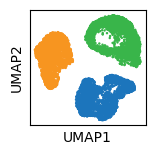

In [2]:
adata_path = large_data_dir + 'CL3_HB_Betaine_0bp_genotype_GF.h5ad'
adata = sc.read_h5ad(adata_path)

adata = adata[adata.obs['BC'] == 'CL3_HB_Betaine_BC001']

fig,ax = plt.subplots(figsize=(1.5,1.5))
sc.pl.umap(adata, color = 'cell_type', ax=ax, show=False, legend_loc=None, title='', palette=color_palette)
plt.savefig('../plots/WTA_CL3_cell_types_umap.pdf', bbox_inches='tight')

In [3]:
## get cell counts to label
adata.obs['cell_type'].value_counts()

cell_type
HEL     3696
K562    3137
SET2    2842
Name: count, dtype: int64

# Find top marker genes and plot

In [4]:
sc.tl.rank_genes_groups(adata, 'cell_type', method='wilcoxon')
top_marker_genes = pd.concat([sc.get.rank_genes_groups_df(adata, group='K562').iloc[0:3], sc.get.rank_genes_groups_df(adata, group='SET2').iloc[0:3], sc.get.rank_genes_groups_df(adata, group='HEL').iloc[[0,2,3]]]).reset_index(drop=True)
top_marker_genes['cell_type'] = ['K562']*3 + ['SET2']*3 + ['HEL']*3
top_marker_genes = top_marker_genes.drop(top_marker_genes['scores'].idxmin()).reset_index(drop=True).copy()

### sort so cell type with only 2 genes comes last
cell_type_order = top_marker_genes['cell_type'].value_counts().index.tolist()
top_marker_genes['cell_type'] = pd.Categorical(top_marker_genes['cell_type'], categories=cell_type_order, ordered=True)
top_marker_genes = top_marker_genes.sort_values(['cell_type', 'scores'], ascending=[True, False]).reset_index(drop=True)


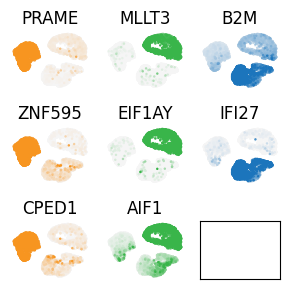

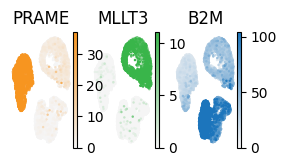

In [5]:
fig,ax = plt.subplots(3,3,figsize=(3,3),sharey=True,sharex=True)
for i, row in enumerate(top_marker_genes.itertuples()):
    q90 = np.percentile(adata[:, row.names].layers['norm_counts'].toarray().ravel(), 90)
    cmap = LinearSegmentedColormap.from_list('custom_cmap', ['whitesmoke',color_palette[row.cell_type]])
    sc.pl.umap(adata, color = row.names, layer = 'norm_counts', cmap = cmap, ax = ax[i%3, i//3], vmax=q90, vmin=0, show=False, frameon=False, colorbar_loc=None)
plt.tight_layout()
plt.savefig('../plots/CL3_HB_Betaine_WTA_marker_genes.pdf')

## replot for legends
fig,ax = plt.subplots(1,3,figsize=(3,1.5),sharey=True,sharex=True)
for i, row in enumerate(top_marker_genes.drop_duplicates(subset='cell_type').itertuples()):
    q90 = np.percentile(adata[:, row.names].layers['norm_counts'].toarray().ravel(), 90)
    cmap = LinearSegmentedColormap.from_list('custom_cmap', ['whitesmoke',color_palette[row.cell_type]])
    sc.pl.umap(adata, color = row.names, layer = 'norm_counts', cmap = cmap, ax = ax[i], vmax=q90, vmin=0, show=False, frameon=False, colorbar_loc='right')
    plt.savefig('../plots/colorbars_CL3_HB_Betaine_WTA_marker_genes.pdf')

    

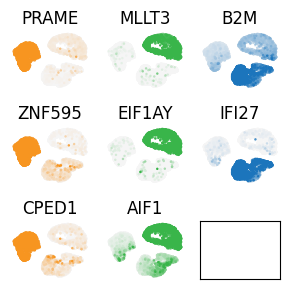

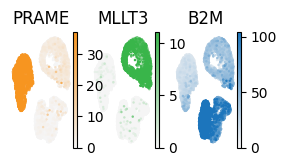

In [6]:
fig,ax = plt.subplots(3,3,figsize=(3,3),sharey=True,sharex=True)
for i, row in enumerate(top_marker_genes.itertuples()):
    q90 = np.percentile(adata[:, row.names].layers['norm_counts'].toarray().ravel(), 90)
    cmap = LinearSegmentedColormap.from_list('custom_cmap', ['whitesmoke',color_palette[row.cell_type]])
    sc.pl.umap(adata, color = row.names, layer = 'norm_counts', cmap = cmap, ax = ax[i%3, i//3], vmax=q90, vmin=0, show=False, frameon=False, colorbar_loc=None)
plt.tight_layout()
plt.savefig('../plots/CL3_HB_Betaine_WTA_marker_genes.pdf')

## replot for legends
fig,ax = plt.subplots(1,3,figsize=(3,1.5),sharey=True,sharex=True)
for i, row in enumerate(top_marker_genes.drop_duplicates(subset='cell_type').itertuples()):
    q90 = np.percentile(adata[:, row.names].layers['norm_counts'].toarray().ravel(), 90)
    cmap = LinearSegmentedColormap.from_list('custom_cmap', ['whitesmoke',color_palette[row.cell_type]])
    sc.pl.umap(adata, color = row.names, layer = 'norm_counts', cmap = cmap, ax = ax[i], vmax=q90, vmin=0, show=False, frameon=False, colorbar_loc='right')
    plt.savefig('../plots/colorbars_CL3_HB_Betaine_WTA_marker_genes.pdf')

    

In [7]:
## get median counts reported in text
adata.obs[['n_genes_by_counts','total_counts']].median()

n_genes_by_counts     5976.0
total_counts         18396.0
dtype: float64